#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Administracion del desarrollo de Software**

##**Tecnológico de Monterrey**

###**Equipo: 5**
###**Proyecto: EduAI Risk Docente**
###**Etapa 2. Entrega sprint 1 del proyecto:**
Revisar valores faltantes, duplicados y tipos de datos. Exportar dataset limpio preliminar.



#**1. Carga de datos y librerías**   

En esta sección se cargan las librerías necesarias para el análisis de datos y se importa el archivo student-mat.csv desde Google Drive. Posteriormente, se visualizan las primeras filas del dataset para verificar que la carga se realizó correctamente.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Ruta del archivo
ruta = '/content/drive/My Drive/Administracion Desarrollo Software/student-mat.csv'

# Cargar dataset
df = pd.read_csv(ruta, sep=';')

# Mostrar las primeras filas
df.head()


Mounted at /content/drive


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


#**2. Exploración general del dataset**   


Antes de realizar la limpieza de los datos, se revisa la estructura general del dataset para conocer la cantidad de registros, variables y el tipo de información almacenada en cada columna.

In [ ]:
# Mostrar número de filas y columnas
print("Dimensiones del dataset:")
print(df.shape)

# Información general del dataset
df.info()


Dimensiones del dataset:
(395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395

#**3. Revisión de valores faltantes**

Se verifica la existencia de valores faltantes en cada una de las columnas del dataset. La identificación temprana de estos valores es importante para garantizar la calidad de los análisis posteriores.

In [ ]:
# Cantidad de valores faltantes por columna
df.isnull().sum()

# Total de valores faltantes en el dataset
print("Total de valores faltantes:", df.isnull().sum().sum())

Total de valores faltantes: 0


#**4. Revisión y eliminacion de registros duplicados**

Se analiza la presencia de registros duplicados dentro del dataset, ya que estos pueden generar sesgos o afectar la interpretación de los resultados. En caso de encontrarse registros duplicados, estos se eliminan para obtener un conjunto de datos más consistente.

In [ ]:
# Verificar registros duplicados
duplicados = df.duplicated().sum()

print("Cantidad de registros duplicados:", duplicados)

# Eliminar registros duplicados
df_limpio = df.drop_duplicates()

print("Dimensiones después de eliminar duplicados:")
print(df_limpio.shape)

Cantidad de registros duplicados: 0
Dimensiones después de eliminar duplicados:
(395, 33)


#**5. Revisión de tipos de datos**

Se revisan los tipos de datos asignados a cada variable para comprobar que la información se encuentra correctamente almacenada y lista para su análisis.

In [ ]:
# Mostrar tipos de datos
df_limpio.dtypes

# Resumen de tipos de datos
df_limpio.dtypes.value_counts()

,count
object,17
int64,16


#**6. Verificación final del dataset limpio**

Se realiza una última comprobación para confirmar que el conjunto de datos no presenta registros duplicados ni valores faltantes después de la limpieza.

In [ ]:
# Comprobación final de valores faltantes
print("Valores faltantes:", df_limpio.isnull().sum().sum())

# Comprobación final de duplicados
print("Duplicados:", df_limpio.duplicated().sum())

Valores faltantes: 0
Duplicados: 0


#**7. Exportación del dataset limpio preliminar**

Finalmente, el conjunto de datos limpio se exporta en formato CSV para utilizarlo en las siguientes etapas del proyecto, como el análisis exploratorio y la generación de visualizaciones.

In [ ]:
# Ruta de salida
ruta_salida = '/content/drive/My Drive/Administracion Desarrollo Software/student-mat-limpio.csv'

# Exportar dataset limpio
df_limpio.to_csv(ruta_salida, index=False)

print("Dataset limpio exportado correctamente.")

Dataset limpio exportado correctamente.


#**8. Visualización: Variables clave relacionadas con el desempeño académico**

Se realiza un análisis de las variables más relacionadas con el desempeño académico de los estudiantes. Se consideran factores como las notas anteriores, el tiempo de estudio, las ausencias, las materias reprobadas y el estado de salud, con el fin de identificar patrones que puedan influir en la nota final (G3).

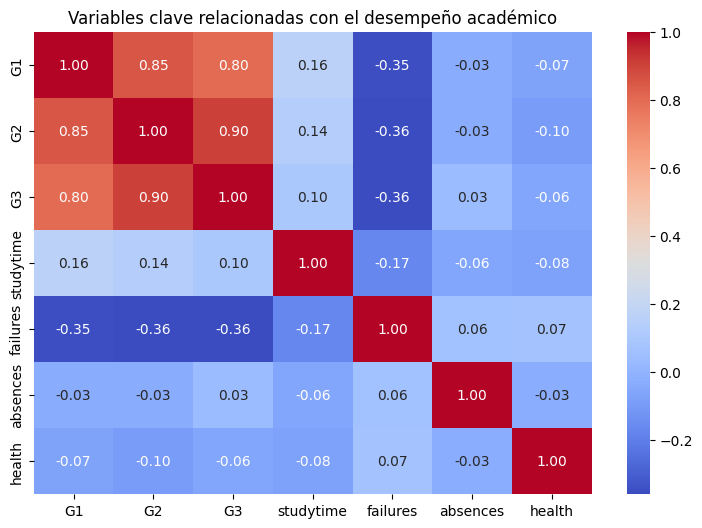

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables clave del desempeño académico
variables = ['G1', 'G2', 'G3', 'studytime', 'failures', 'absences', 'health']

# Matriz de correlación
corr = df_limpio[variables].corr()

# Mapa de calor
plt.figure(figsize=(9,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Variables clave relacionadas con el desempeño académico')
plt.show()

Esta visualización permite observar las relaciones entre diferentes factores académicos y personales con la nota final. Se puede notar que las notas anteriores (G1 y G2) tienen una fuerte relación con G3, mientras que variables como failures y absences tienden a afectar negativamente el rendimiento académico.